In [1]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

## 1. Retrieve the files with path images

In [2]:

metadata_dir = '/export/usuarios_ml4ds/danibacaicoa/ForwardBackard_losses_old/Datasets/raw_datasets/Clothing1M/'
clean_label_kv_path = os.path.join(metadata_dir, 'clean_label_kv.txt')
noisy_label_kv_path = os.path.join(metadata_dir, 'noisy_label_kv.txt')
clean_train_key_list_path = os.path.join(metadata_dir, 'clean_train_key_list.txt')
noisy_train_key_list_path = os.path.join(metadata_dir, 'noisy_train_key_list.txt')
clean_val_key_list_path = os.path.join(metadata_dir, 'clean_val_key_list.txt')
clean_test_key_list_path = os.path.join(metadata_dir, 'clean_test_key_list.txt')
category_names_eng_path = os.path.join(metadata_dir, 'category_names_eng.txt')


## 2. 

In [3]:
def load_labels(filepath):
    """Loads image path -> label mapping from a file."""
    labels = {}

    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:

                image_path = os.path.normpath(parts[0])
                labels[image_path] = int(parts[1])
            else:

                pass # print(f"Warning: Skipping malformed line in {filepath}: {line.strip()}")
    return labels

def load_key_list(filepath):
    """Loads a list of image paths from a file."""
    keys = []

    with open(filepath, 'r') as f:
        for line in f:

            image_path = os.path.normpath(line.strip())
            if image_path: # Ensure line is not empty
                keys.append(image_path)
    return keys


In [4]:
# Load category names
category_names = None

if os.path.exists(category_names_eng_path):
    with open(category_names_eng_path, 'r') as f:
        category_names = [line.strip() for line in f if line.strip()]

print(f"Loaded {len(category_names)} category names.")
print(f"Category names: {category_names}")

c = len(category_names)
print(f"Number of categories: {c}")


Loaded 14 category names.
Category names: ['T-Shirt', 'Shirt', 'Knitwear', 'Chiffon', 'Sweater', 'Hoodie', 'Windbreaker', 'Jacket', 'Downcoat', 'Suit', 'Shawl', 'Dress', 'Vest', 'Underwear']
Number of categories: 14


In [39]:
class Clothing1MDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        Args:
            root_dir (string): Directory with all the images (should contain 'images' folder).
            split (string): One of 'train', 'val', 'test'.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.split = split
        self.samples = [] # List of tuples: (image_path_relative, label, noisy_flag)

        print(f"Initializing Clothing1M dataset for split: {split}")

        # --- Load label dictionaries ---
        print("Doing {split} split...\n")
        print("Loading label files...")
        clean_labels = load_labels(clean_label_kv_path)
        noisy_labels = load_labels(noisy_label_kv_path)
        print(f"Loaded {len(clean_labels)} clean labels and {len(noisy_labels)} noisy labels.")
        print("Checking label files...")
        print(f"Clean labels: {[{k: clean_labels[k] for k in sorted(clean_labels.keys())[:2]}]}")
        print(f"Noisy labels: {[{k: noisy_labels[k] for k in sorted(noisy_labels.keys())[:2]}]}")


        # --- Load the appropriate key lists based on the split --
        print("Loading key list files...")
        if split == 'train':
            clean_keys = load_key_list(clean_train_key_list_path)
            noisy_keys = load_key_list(noisy_train_key_list_path)

            self.N = np.zeros((c,c)) 

            print(f"Found {len(clean_keys)} clean train keys and {len(noisy_keys)} noisy train keys.")

            #Add noisy taining samples
            missing_noisy_labels_count = 0
            for key in noisy_keys:
                if key in noisy_labels:
                    self.samples.append((key, np.eye(c)[noisy_labels[key]], 1)) # 1 for noisy
                    if key in clean_labels:
                        print("There is a key in both noisy and clean labels. This is not expected.")
                        self.N[noisy_labels[key], clean_labels[key]] = self.N[noisy_labels[key], clean_labels[key]]+ 1
                else:
                    missing_noisy_labels_count += 1
            if missing_noisy_labels_count > 0:
                print(f"Warning: {missing_noisy_labels_count} noisy train keys were not found in noisy_label_kv.txt")

            # Add clean training samples
            missing_clean_labels_count = 0
            for key in clean_keys:
                if key in clean_labels and key not in noisy_labels:
                    self.samples.append((key, np.eye(c)[clean_labels[key]], 0)) # 0 for clean
                else:
                     missing_clean_labels_count += 1
            if missing_clean_labels_count > 0:
                 print(f"Warning: {missing_clean_labels_count} clean train keys were not found in clean_label_kv.txt or were loade with noisy labels.")
            '''
            # Add noisy training samples
            missing_noisy_labels_count = 0
            noisy_in_clean_found_count = 0
            for key in noisy_keys:
                if key in noisy_labels:
                    self.samples.append((key, noisy_labels[key], 1)) # 1 for noisy
                else:
                    # Fallback: check if it's accidentally in clean labels
                    if key in clean_labels:
                         noisy_in_clean_found_count += 1
                         self.samples.append((key, clean_labels[key], 0)) # Treat as clean if found in clean dict
                    else:
                         missing_noisy_labels_count += 1
            if noisy_in_clean_found_count > 0:
                 print(f"Warning: {noisy_in_clean_found_count} noisy train keys were found in clean_label_kv.txt instead of noisy_label_kv.txt. Labeling them as clean (noisy_flag=0).")
            if missing_noisy_labels_count > 0:
                 print(f"Warning: {missing_noisy_labels_count} noisy train keys were not found in noisy_label_kv.txt or clean_label_kv.txt")
            '''
        elif split == 'val':
            val_keys = load_key_list(clean_val_key_list_path)
            if val_keys is None:
                 raise RuntimeError("Failed to load validation key list. Check path and file integrity.")
            print(f"Found {len(val_keys)} validation keys.")
            # Validation set uses clean labels
            missing_val_labels_count = 0
            for key in val_keys:
                if key in clean_labels:
                    self.samples.append((key, np.eye(c)[clean_labels[key]], 0)) # Val is clean
                else:
                    missing_val_labels_count += 1
            if missing_val_labels_count > 0:
                print(f"Warning: {missing_val_labels_count} validation keys were not found in clean_label_kv.txt")

        elif split == 'test':
            test_keys = load_key_list(clean_test_key_list_path)
            if test_keys is None:
                 raise RuntimeError("Failed to load test key list. Check path and file integrity.")
            print(f"Found {len(test_keys)} test keys.")

            # Test set uses clean labels
            missing_test_labels_count = 0
            for key in test_keys:
                if key in clean_labels:
                    self.samples.append((key, clean_labels[key], 0)) # Test is clean
                else:
                    missing_test_labels_count += 1
            if missing_test_labels_count > 0:
                print(f"Warning: {missing_test_labels_count} test keys were not found in clean_label_kv.txt")

        else:
            raise ValueError(f"Invalid split name: {split}. Choose 'train', 'val', or 'test'.")

        print(f"-> Total samples loaded for split '{split}': {len(self.samples)}")
        if len(self.samples) == 0:
             print(f"\nCRITICAL WARNING: No samples were loaded for split '{split}'.\n"
                   f"Check that the paths to the key list files ({split}_key_list.txt) and label files (clean_label_kv.txt, noisy_label_kv.txt) are correct relative to your notebook's location.\n"
                   f"Also ensure the files are not empty and have the expected format (e.g., 'images/X/Y/Z.jpg label').")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        relative_img_path, label, noisy_flag = self.samples[idx]
        # Construct full path using os.path.join for cross-platform compatibility
        img_full_path = os.path.join(self.root_dir, relative_img_path)

        try:
            # Load image
            image = Image.open(img_full_path).convert('RGB')
        except FileNotFoundError:
            # This can happen if the dataset is incomplete or paths are wrong
            # print(f"Error: Image file not found at {img_full_path}. Returning dummy data.")
            # Return dummy data or raise an error, depending on desired behavior
            image = Image.new('RGB', (224, 224), color = 'red') # Example dummy image
            label = -1 # Indicate error
            noisy_flag = -1 # Indicate error
            # Alternatively: raise FileNotFoundError(f"Image not found: {img_full_path}")
        except Exception as e:
            # Catch other PIL errors (e.g., truncated image)
            # print(f"Error loading image {img_full_path}: {e}. Returning dummy data.")
            image = Image.new('RGB', (224, 224), color = 'blue') # Different dummy color for different errors
            label = -1
            noisy_flag = -1

        # Apply transformations
        if self.transform:
            # Add a try-except block here if transforms might fail
            try:
                image = self.transform(image)
            except Exception as e:
                print(f"Error applying transform to image {img_full_path}: {e}. Returning dummy tensor.")
                image = torch.zeros((3, 224, 224), dtype=torch.float32) # Dummy tensor
                label = -1
                noisy_flag = -1

        return image, label, noisy_flag


In [40]:
# Define transforms (adjust as needed for your model)
img_size = 224
# For training: include resizing, augmentation (like horizontal flip), tensor conversion, normalization
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    # Add other augmentations like RandomCrop, ColorJitter if needed
    # transforms.RandomCrop(img_size, padding=4), # Example
    # transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1), # Example
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats commonly used
])

# For validation/testing: include resizing, tensor conversion, normalization (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined.")


Transforms defined.


In [41]:
clothing1m_root = '/export/usuarios_ml4ds/danibacaicoa/ForwardBackard_losses_old/Datasets/raw_datasets/Clothing1M/' 
#clothing1m_root = './clothing1m' # <-- CHANGE THIS TO YOUR ACTUAL PATH

# --- Directory Check ---
root_ok = False
print(f"Checking dataset root directory: {clothing1m_root}")
if not os.path.isdir(clothing1m_root):
     print(f"Error: Root directory '{clothing1m_root}' not found or is not a directory.")
     print("Please ensure the path is correct and points to the folder *containing* the 'images' directory.")
else:
    images_dir = os.path.join(clothing1m_root, 'images/')
    print(f"Checking for 'images' sub-directory: {images_dir}")
    if not os.path.isdir(images_dir):
         print(f"Error: Expected 'images' sub-directory not found inside '{clothing1m_root}'.")
         print("Please ensure the 'images' folder exists directly within the specified root directory.")
    else:
        print(f"Dataset root directory check passed: '{clothing1m_root}' contains 'images' folder.")
        root_ok = True

if not root_ok:
     print("\n!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
     print("!!! Cannot proceed without a valid dataset root directory path. !!!")
     print("!!! Please correct the 'clothing1m_root' variable and rerun.    !!!")
     print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")


Checking dataset root directory: /export/usuarios_ml4ds/danibacaicoa/ForwardBackard_losses_old/Datasets/raw_datasets/Clothing1M/
Checking for 'images' sub-directory: /export/usuarios_ml4ds/danibacaicoa/ForwardBackard_losses_old/Datasets/raw_datasets/Clothing1M/images/
Dataset root directory check passed: '/export/usuarios_ml4ds/danibacaicoa/ForwardBackard_losses_old/Datasets/raw_datasets/Clothing1M/' contains 'images' folder.


In [43]:
train_dataset = None
#val_dataset = None
test_dataset = None
train_loader = None
#val_loader = None
test_loader = None

# Proceed only if the root directory check passed
if root_ok:
    try:
        # Create datasets
        print("\n--- Creating Train Dataset ---")
        # Pass the already defined transform
        train_dataset = Clothing1MDataset(root_dir=clothing1m_root, split='train', transform=train_transform)


        print("\n--- Creating Test Dataset ---")
        test_dataset = Clothing1MDataset(root_dir=clothing1m_root, split='test', transform=val_test_transform)

        # Create dataloaders
        batch_size = 64 # Adjust as needed based on GPU memory and model size
        num_workers = 2   # Adjust based on your system's cores (start with 0 or 2); set to 0 if you encounter multiprocessing issues

        print("\n--- Creating DataLoaders ---")
        if train_dataset and len(train_dataset) > 0:
             # Consider using persistent_workers=True if num_workers > 0 for efficiency in PyTorch 1.7+
             # Set prefetch_factor=2 if using num_workers > 0
             train_loader = DataLoader(
                 train_dataset,
                 batch_size=batch_size,
                 shuffle=True,
                 num_workers=num_workers,
                 pin_memory=True, # Helps speed up CPU-to-GPU transfer if using GPU
                 # persistent_workers=True if num_workers > 0 else False, # Uncomment if needed
                 # prefetch_factor=2 if num_workers > 0 else None # Uncomment if needed
                 drop_last=True # Often useful for training stability
             )
             print(f"Train DataLoader created with batch size {batch_size}, {len(train_loader)} batches.")
        else:
             print("Skipping Train DataLoader creation as dataset is empty or failed to initialize.")


        if test_dataset and len(test_dataset) > 0:
             test_loader = DataLoader(
                 test_dataset,
                 batch_size=batch_size * 2,
                 shuffle=False,
                 num_workers=num_workers,
                 pin_memory=True
                 # persistent_workers=True if num_workers > 0 else False,
                 # prefetch_factor=2 if num_workers > 0 else None
             )
             print(f"Test DataLoader created with batch size {batch_size * 2}, {len(test_loader)} batches.")
        else:
             print("Skipping Test DataLoader creation as dataset is empty or failed to initialize.")

    except (RuntimeError, ValueError, FileNotFoundError) as e:
        print(f"\nAn error occurred during dataset/dataloader creation: {e}")
        print("Please double-check file paths, file contents, and the dataset root directory.")
    except Exception as e: # Catch any other unexpected errors
        import traceback
        print(f"\nAn unexpected error occurred: {e}")
        print(traceback.format_exc())
else:
    print("\nSkipping Dataset and DataLoader creation due to issues with the root directory path.")



# Example: Get one batch from the train loader if it was created
if train_loader is not None:
    print("\n--- Inspecting Training Batch ---")
    try:
        # Create an iterator and get the first batch
        data_iter = iter(train_loader)
        images, labels, noisy_flags = next(data_iter) # This fetches one batch

        print("Successfully fetched one batch.")
        print("Images shape:", images.shape)      # Example: [batch_size, 3, 224, 224]
        print("Labels shape:", labels.shape)        # Example: [batch_size]
        print("Noisy flags shape:", noisy_flags.shape) # Example: [batch_size]

        # --- Inspect the first item in the batch ---
        print("\nExample data from the first item in the batch:")
        first_label = labels[0]
        first_noisy_flag = noisy_flags[0].item()
        print("Label:", first_label)
        print("Is Noisy:", "Yes" if first_noisy_flag == 1 else "No (Clean)")

        # Print category name if available and label is valid
        if category_names:
            if 0 <= first_label < len(category_names):
                 print("Category Name:", category_names[first_label])
            elif first_label == -1:
                 print("Category Name: Invalid label due to loading error (-1)")
            else:
                 print(f"Category Name: Invalid label index ({first_label}) for category names list (len={len(category_names)})")
        else:
            print("Category names not loaded.")

        # --- Display the first image in the batch ---
        print("\nDisplaying first image (denormalized):")
        first_image = images[0] # Get the first image tensor from the batch
        # Convert CHW tensor to HWC numpy array for display
        img_display = first_image.permute(1, 2, 0).cpu().numpy()

        # Denormalize the image (reverse the normalization applied by transforms)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1) # Clip values to [0, 1] range

        plt.figure(figsize=(5,5))
        plt.imshow(img_display)
        title = f'Label: {first_label}'
        if category_names and 0 <= first_label < len(category_names):
            title += f' ({category_names[first_label]})'
        title += f'\nNoisy: {"Yes" if first_noisy_flag == 1 else "No"}'
        plt.title(title)
        plt.axis('off') # Hide axes
        plt.show()

    except StopIteration:
        print("Could not fetch a batch. The train loader appears to be empty or exhausted.")
    except Exception as e:
        print(f"An error occurred while fetching or inspecting the batch: {e}")
        import traceback
        print(traceback.format_exc())
else:
    print("\nTrain loader is not available (was not created successfully or root path was invalid). Cannot inspect batch.")



--- Creating Train Dataset ---
Initializing Clothing1M dataset for split: train
Doing {split} split...

Loading label files...
Loaded 72409 clean labels and 1037497 noisy labels.
Checking label files...
Clean labels: [{'images/0/00/1278541879,867148000.jpg': 13, 'images/0/00/1298176222,2755628000.jpg': 11}]
Noisy labels: [{'images/0/00/1002421923,3049250000.jpg': 11, 'images/0/00/1012738279,747514000.jpg': 7}]
Loading key list files...
Found 47570 clean train keys and 1000000 noisy train keys.
-> Total samples loaded for split 'train': 1022933

--- Creating Test Dataset ---
Initializing Clothing1M dataset for split: test
Doing {split} split...

Loading label files...
Loaded 72409 clean labels and 1037497 noisy labels.
Checking label files...
Clean labels: [{'images/0/00/1278541879,867148000.jpg': 13, 'images/0/00/1298176222,2755628000.jpg': 11}]
Noisy labels: [{'images/0/00/1002421923,3049250000.jpg': 11, 'images/0/00/1012738279,747514000.jpg': 7}]
Loading key list files...
Found 1052

In [45]:
train_dataset[0]

(tensor([[[2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          ...,
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489]],
 
         [[2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          ...,
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286]],
 
         [[2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400, 2.6400,  ...,

In [38]:
np.eye(c)[2]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [9]:
train_dataset.N

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])


Estimating Transition Matrix directly from label files...
Loading clean labels from file...
Loading noisy labels from file...
Found 72409 clean label entries and 1037497 noisy label entries.
Found 37497 images present in both clean and noisy label sets.

Raw Count Matrix (Rows=Clean, Cols=Noisy):
[[1798  231  188  601  296   75    3    6   13   16    9  175  266  164]
 [  84 2205   31  823   13   29   23   99   28   24   17   63   36   18]
 [ 199   32  607   62 1280  108   27    0    6   33   84  137   58   41]
 [  64  130   10 1820    9    5    0    0    2    5    5   75   50    1]
 [  42    4  379    5  230   18    2    0    1    3    6   10    1   66]
 [ 166    8   33   11   54 1980   34   36   52    6    2   16    2   32]
 [   1   11   10    6    6   96 1232  303  560  440   33   91    0    3]
 [  78   88    7    9    3  488  180  586  410  146    4    9   74    5]
 [   3    7    1    0    0   30  445   47 1667    2    0    3    0    0]
 [   7   38    5    4    2   28  103    3   

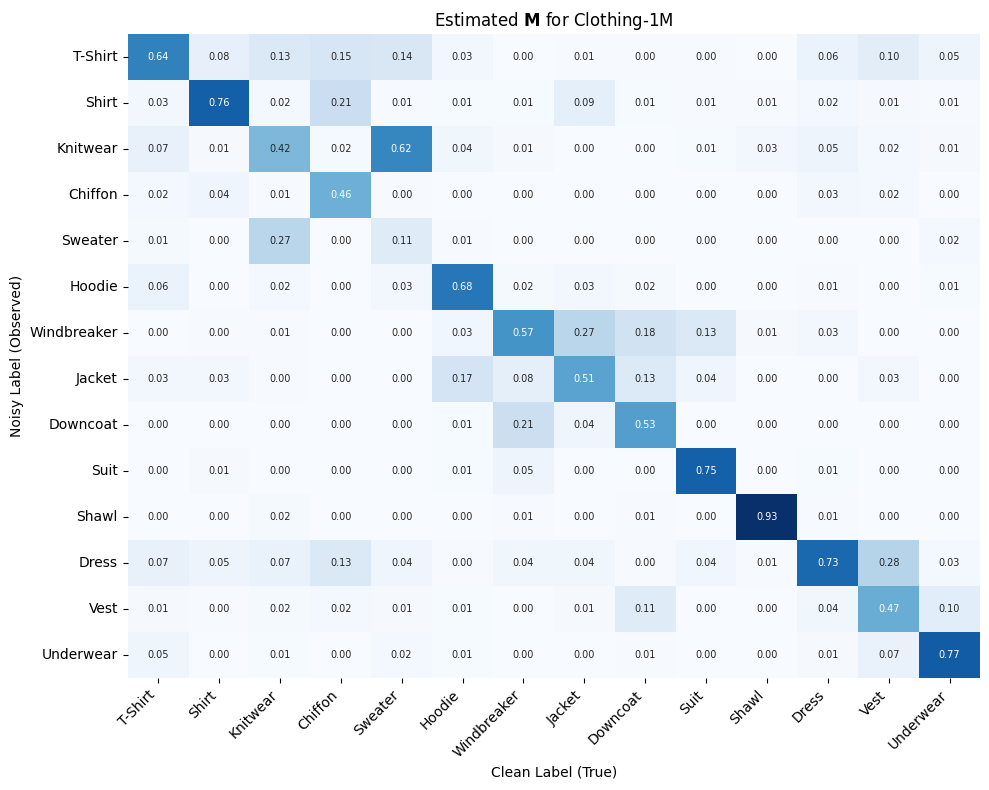

In [46]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

num_classes = c # Number of classes (categories) in the dataset


def estimate_transition_matrix(clean_labels_path, noisy_labels_path, num_classes):
    """
    Estimates the transition matrix T where T[i, j] = P(noisy=j | clean=i)
    by comparing full clean and noisy label mappings.

    Args:
        clean_labels_path (str): Path to the clean label file (e.g., clean_label_kv.txt).
        noisy_labels_path (str): Path to the noisy label file (e.g., noisy_label_kv.txt).
        num_classes (int): The total number of classes.

    Returns:
        numpy.ndarray: The estimated transition matrix (num_classes x num_classes),
                       or None if loading fails.
    """
    print("Loading clean labels from file...")
    clean_labels = load_labels(clean_labels_path)
    print("Loading noisy labels from file...")
    noisy_labels = load_labels(noisy_labels_path)

    if clean_labels is None or noisy_labels is None:
        print("Error: Failed to load one or both label files. Cannot estimate matrix.")
        return None

    if num_classes <= 0:
        print("Error: num_classes must be positive.")
        return None

    print(f"Found {len(clean_labels)} clean label entries and {len(noisy_labels)} noisy label entries.")

    common_keys = set(clean_labels.keys()) & set(noisy_labels.keys())
    print(f"Found {len(common_keys)} images present in both clean and noisy label sets.")

    if not common_keys:
        print("Error: No common images found between clean and noisy sets. Cannot estimate matrix.")
        return None

    count_matrix = np.zeros((num_classes, num_classes), dtype=float)
    invalid_labels_count = 0
    for key in common_keys:
        clean_label = clean_labels[key]
        noisy_label = noisy_labels[key]
        if 0 <= clean_label < num_classes and 0 <= noisy_label < num_classes:
            count_matrix[noisy_label,clean_label] += 1.0
        else:
            invalid_labels_count += 1
    if invalid_labels_count > 0:
         print(f"Warning: Skipped {invalid_labels_count} pairs due to invalid label indices (out of bounds).")

    print("\nRaw Count Matrix (Rows=Clean, Cols=Noisy):")
    with np.printoptions(threshold=np.inf, suppress=True):
         print(count_matrix.astype(int))

    epsilon = 1e-8
    row_sums = count_matrix.sum(axis=1, keepdims=True)
    zero_sum_rows = np.where(row_sums < epsilon)[0]
    if len(zero_sum_rows) > 0:
        print(f"\nWarning: The following clean classes had no samples in the clean/noisy intersection:")
        print(f"Indices: {zero_sum_rows}")
        if category_names: print(f"Names: {[category_names[i] for i in zero_sum_rows]}")
        print("Their rows in the transition matrix will be zero.")

    transition_matrix = count_matrix / np.sum(count_matrix, axis=0, keepdims=True)
    return transition_matrix

# --- Main Execution ---
if num_classes > 0:
    print("\nEstimating Transition Matrix directly from label files...")
    T = estimate_transition_matrix(clean_label_kv_path, noisy_label_kv_path, num_classes)

    if T is not None:
        print("\nOriginal Estimated Transition Matrix T (Rows=Clean, Cols=Noisy):")
        np.set_printoptions(precision=5, suppress=True)
        print(T)
        print(f"\nMatrix T shape: {T.shape}")

        # --- Calculate and Print Transposed Matrix ---
        T_transpose = T.T
        print("\nTransposed Transition Matrix T_transpose (Rows=Noisy, Cols=Clean):")
        print(T_transpose)
        print(f"\nMatrix T_transpose shape: {T_transpose.shape}")
        print("\nReminder: T_transpose[j, i] still represents P(noisy=j | clean=i)")

        # --- Visualize Both Matrices ---
        tick_labels = category_names if category_names and len(category_names) == num_classes else range(num_classes)
        plot_annot_kws={"size": 7} # Smaller font size for annotations

        try:
            # Visualize Original T
            plt.figure(figsize=(10, 8))
            sns.heatmap(T, annot=True, fmt=".2f", cmap="Blues",
                        xticklabels=tick_labels, yticklabels=tick_labels, annot_kws=plot_annot_kws,cbar=False)
            plt.ylabel("Noisy Label (Observed)")
            plt.xlabel("Clean Label (True)")
            plt.title(r'Estimated $\mathbf{M}$ for Clothing-1M')
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"\nCould not visualize matrices: {e}")
            print("Ensure matplotlib and seaborn are installed (`pip install matplotlib seaborn`)")

else:
    print("\nCannot estimate matrix because num_classes was not determined.")


In [47]:
M = T

In [48]:
import numpy as np

# Given matrix M
'''
M = np.array([
    [0.641, 0.079, 0.132, 0.152, 0.144, 0.026, 0.001, 0.005, 0.004, 0.005, 0.003, 0.062, 0.1,   0.048],
    [0.03,  0.757, 0.022, 0.208, 0.006, 0.01,  0.011, 0.087, 0.009, 0.007, 0.006, 0.022, 0.014, 0.005],
    [0.071, 0.011, 0.425, 0.016, 0.623, 0.037, 0.013, 0.0,   0.002, 0.01,  0.03,  0.049, 0.022, 0.012],
    [0.023, 0.045, 0.007, 0.461, 0.004, 0.002, 0.0,   0.0,   0.001, 0.002, 0.002, 0.027, 0.019, 0.0],
    [0.015, 0.001, 0.265, 0.001, 0.112, 0.006, 0.001, 0.0,   0.0,   0.001, 0.002, 0.004, 0.0,   0.019],
    [0.059, 0.003, 0.023, 0.003, 0.026, 0.675, 0.016, 0.032, 0.017, 0.002, 0.001, 0.006, 0.001, 0.009],
    [0.0,   0.004, 0.007, 0.002, 0.003, 0.033, 0.572, 0.266, 0.178, 0.133, 0.012, 0.032, 0.0,   0.001],
    [0.028, 0.03,  0.005, 0.002, 0.001, 0.166, 0.084, 0.515, 0.131, 0.044, 0.001, 0.003, 0.028, 0.001],
    [0.001, 0.002, 0.001, 0.0,   0.0,   0.01,  0.207, 0.041, 0.531, 0.001, 0.0,   0.001, 0.0,   0.0],
    [0.002, 0.013, 0.003, 0.001, 0.001, 0.01,  0.048, 0.003, 0.004, 0.754, 0.003, 0.009, 0.0,   0.002],
    [0.0,   0.0,   0.016, 0.0,   0.002, 0.001, 0.005, 0.001, 0.005, 0.002, 0.93,  0.006, 0.0,   0.001],
    [0.07,  0.047, 0.067, 0.131, 0.043, 0.005, 0.039, 0.039, 0.004, 0.036, 0.006, 0.73,  0.281, 0.025],
    [0.014, 0.004, 0.017, 0.023, 0.013, 0.01,  0.003, 0.011, 0.11,  0.003, 0.004, 0.039, 0.47,  0.103],
    [0.045, 0.003, 0.01,  0.0,   0.02,  0.011, 0.002, 0.0,   0.005, 0.0,   0.001, 0.012, 0.066, 0.771]
])
'''
n = M.shape[0]
eps = 1e-3
lr = 1e-2

# Initialize A in (eps, 1-eps), B >= 0, both column-stochastic
rng = np.random.default_rng(42)
A = rng.uniform(eps, 1-eps, size=(n,n))
A /= A.sum(axis=0, keepdims=True)
B = rng.random((n,n))
B /= B.sum(axis=0, keepdims=True)

# Alternating projected gradient descent
err = 999
it = 0
while err > 3e-2:
    # gradient w.r.t. A
    gradA = (A.dot(B) - M).dot(B.T)
    A -= lr * gradA
    # project A to [eps,1-eps] and column-normalize
    A = np.clip(A, eps, 1-eps)
    A /= A.sum(axis=0, keepdims=True)

    # gradient w.r.t. B
    gradB = A.T.dot(A.dot(B) - M)
    B -= lr * gradB
    # project B to [0, inf) and column-normalize
    B = np.maximum(B, 0)
    B /= B.sum(axis=0, keepdims=True)

    err = np.linalg.norm(A.dot(B) - M, 'fro')
    it += 1
    if it % 100 == 0:
        print(f"Iteration {it}: Frobenius error = {err:.6e}")
# Final error
error = np.linalg.norm(A.dot(B) - M, 'fro')
print(f"\nFinal Frobenius error after {it} iterations: {error:.6e}")

# A and B now satisfy:
# - A in (0,1)^{14x14}, column-stochastic
# - B >= 0, column-stochastic
# - A @ B ≈ M


Iteration 100: Frobenius error = 2.218425e+00
Iteration 200: Frobenius error = 2.091331e+00
Iteration 300: Frobenius error = 1.967375e+00
Iteration 400: Frobenius error = 1.842453e+00
Iteration 500: Frobenius error = 1.709785e+00
Iteration 600: Frobenius error = 1.589762e+00
Iteration 700: Frobenius error = 1.500616e+00
Iteration 800: Frobenius error = 1.421189e+00
Iteration 900: Frobenius error = 1.338390e+00
Iteration 1000: Frobenius error = 1.254964e+00
Iteration 1100: Frobenius error = 1.172982e+00
Iteration 1200: Frobenius error = 1.090596e+00
Iteration 1300: Frobenius error = 1.010217e+00
Iteration 1400: Frobenius error = 9.338194e-01
Iteration 1500: Frobenius error = 8.628697e-01
Iteration 1600: Frobenius error = 7.985199e-01
Iteration 1700: Frobenius error = 7.409852e-01
Iteration 1800: Frobenius error = 6.911334e-01
Iteration 1900: Frobenius error = 6.499897e-01
Iteration 2000: Frobenius error = 6.144601e-01
Iteration 2100: Frobenius error = 5.815045e-01
Iteration 2200: Froben

In [49]:
print(np.sum(A, axis=0), np.sum(B, axis=0))
print(A@B-M)
print('A:',A)
print('B:',B)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[[-0.0028  -0.0001   0.00006 -0.0011  -0.00048  0.00017  0.00113  0.00103
  -0.00008 -0.00002 -0.00001  0.0001  -0.00071 -0.00011]
 [ 0.00011 -0.00204 -0.00005 -0.00136  0.00015 -0.      -0.00014 -0.00035
  -0.00004  0.00005 -0.00001  0.00011  0.00006 -0.00006]
 [ 0.0002  -0.00001 -0.00002  0.00001 -0.00307 -0.00007 -0.0001   0.00178
   0.00002 -0.00002 -0.00006 -0.00005 -0.00002  0.00003]
 [ 0.00051  0.0007  -0.00002 -0.0081   0.00006 -0.00003  0.00215  0.00157
   0.00036 -0.00001 -0.       0.00063  0.00038  0.00073]
 [-0.00013  0.00032 -0.00099  0.00056  0.00028  0.00025  0.0001   0.001
   0.00074  0.00016  0.00001 -0.0001   0.00211 -0.00017]
 [-0.      -0.00033  0.00008 -0.00002 -0.00031 -0.00099  0.00007  0.00321
  -0.0005   0.0002   0.00114 -0.00015  0.0009  -0.00007]
 [ 0.00152  0.00024 -0.00034  0.00266  0.00041  0.00003 -0.01265 -0.00208
   0.00326  0.0007   0.00004 -0.00115  0.00734  0.0001

## Training ResNet50 pretrained in Imagenet

In [36]:
np.linalg.inv(M).shape

(14, 14)

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import random
import copy # To keep track of the best model
# Assuming you have DataLoader defined elsewhere
# from torch.utils.data import DataLoader

# --- Configuration ---
# !!! User needs to adjust these parameters !!!
NUM_CLASSES = 14  # Replace with the actual number of classes in your dataset
BATCH_SIZE = 32   # Should match the batch size used in your DataLoaders if needed elsewhere, otherwise informational
NUM_EPOCHS = 25
LEARNING_RATE = 0.001
# Use GPU if available, otherwise use CPU
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")



#train_dataset
#test_dataset
#trainloader
#testloader
train_dataset_size = len(train_dataset)
test_dataset_size = len(test_dataset)
# !!! --- End of User Provided DataLoaders --- !!!


print(f"Training dataset size: {train_dataset_size}")
print(f"Validation/Test dataset size: {test_dataset_size}")


# --- Model Loading and Modification ---
print("Loading pre-trained ResNet-50 model...")
# Load the pre-trained ResNet-50 model
model_ft = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# --- Freeze all layers except the final classifier ---
print("Freezing base model parameters...")
for param in model_ft.parameters():
    param.requires_grad = False

# --- Replace the final layer (the classifier) ---
num_ftrs = model_ft.fc.in_features
print(f"Original ResNet FC layer input features: {num_ftrs}")
print(f"Replacing FC layer to output {NUM_CLASSES} classes.")
model_ft.fc = nn.Linear(num_ftrs, NUM_CLASSES)

# Ensure the parameters of the new final layer require gradients
for param in model_ft.fc.parameters():
    param.requires_grad = True

# Move the model to the specified device (GPU or CPU)
model_ft = model_ft.to(DEVICE)

# --- Define Loss Function and Optimizer ---

# !!! This is where you define YOUR custom loss function !!!
# Example using standard CrossEntropyLoss:
# criterion = nn.CrossEntropyLoss()
# Replace the line above with your custom loss:
# class MyCustomLoss(nn.Module):
#     def __init__(self, ...): # Add any params your loss needs
#         super().__init__()
#         # ... initialize parts of your loss ...
#     def forward(self, outputs, labels):
#         # ... implement your loss calculation ...
#         loss = ...
#         return loss
# criterion = MyCustomLoss(...)
class FwdBwdLoss(nn.Module):
    def __init__(self, B, F, k = 0, beta = 1):
        super(FwdBwdLoss, self).__init__()
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.logsotmax = torch.nn.LogSoftmax(dim=1)
        self.softmax = torch.nn.Softmax(dim=1)
        self.B = torch.tensor(B, dtype=torch.float32, device=device)
        self.F = torch.tensor(F, dtype=torch.float32, device=device)
        self.k = torch.tensor(k, dtype=torch.float32, device=device)
        self.beta = torch.tensor(beta, dtype=torch.float32, device=device)

    def forward(self, inputs, z):
        v = inputs - torch.mean(inputs, axis = 1, keepdims = True)
        p = self.softmax(v)
        z = z.long()

        # Loss is computed as z'B'*phi(Ff)
        Ff = self.F @ p.T 
        log_Ff = torch.log(Ff+1e-8)
        B_log_Ff = self.B.T @ log_Ff
        L = - torch.sum(B_log_Ff[z,range(B_log_Ff.size(1))]) + 0.5 * self.k * torch.sum(torch.abs(v)**self.beta)
        #L = - torch.sum(B_log_Ff[z,range(B_log_Ff.size(1))]+1e-10)
        return L

#Backward
loss_fn = FwdBwdLoss(np.linalg.inv(M), np.eye(c))
##Forward
#loss_fn = FwdBwdLoss(np.eye(c), M)

#'FB_decomposed'
# IA = np.linalg.inv(A)
#loss_fn = FwdBwdLoss(IA, B)


# Define the optimizer (only optimizing the new classifier parameters)
params_to_optimize = filter(lambda p: p.requires_grad, model_ft.parameters())
optimizer_ft = optim.Adam(params_to_optimize, lr=LEARNING_RATE)

# (Optional) Learning rate scheduler
# lr_scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step

Using device: cuda:0
Training dataset size: 1022933
Validation/Test dataset size: 10526
Loading pre-trained ResNet-50 model...
Freezing base model parameters...
Original ResNet FC layer input features: 2048
Replacing FC layer to output 14 classes.


In [52]:
# --- Helper Function to Get Targets (Handles both class indices and one-hot) ---
def get_true_labels(targets, device):
    """
    Helper function to get the actual class labels from the targets tensor,
    handling both class indices (shape [N]) and one-hot encoded labels (shape [N, C]).
    """
    targets = targets.to(device)
    # Check if targets are one-hot encoded (more than 1 dimension and size > 1 in the last dim)
    if targets.ndim > 1 and targets.shape[-1] > 1:
        return torch.max(targets, dim=1)[1] # Get indices from one-hot
    else:
        # Assume targets are already class indices (long tensor)
        # Ensure it's on the correct device and dtype
        return targets.long().to(device)

# --- Adapted Training and Evaluation Function ---
def train_and_evaluate(model, trainloader, testloader, optimizer, loss_fn, num_epochs, corr_p, rep = None, sound=10, loss_type = None):
    """
    Trains and evaluates a model, mimicking the structure and output of the user's provided loop.

    Args:
        model (torch.nn.Module): The neural network model.
        trainloader (DataLoader): DataLoader for the training set.
                                  Expected to yield (inputs, vl, targets).
                                  'vl' is used for the primary loss_fn.
                                  'targets' is used for accuracy calculation.
        testloader (DataLoader): DataLoader for the test/validation set.
                                 Expected to yield (inputs, targets).
        optimizer (torch.optim.Optimizer): The optimizer to use.
        loss_fn (callable): The primary loss function (e.g., custom loss). Takes model output and 'vl'.
        num_epochs (int): Number of epochs to train.
        corr_p: User-defined parameter to be stored in results (e.g., corruption probability).
        rep (any, optional): User-defined parameter for repetition number. Defaults to None.
        sound (int, optional): Print detailed epoch summary every 'sound' epochs. Defaults to 10.
        loss_type (str, optional): Name or type of the primary loss function for logging. Defaults to None.

    Returns:
        tuple: (model, results_df)
            - model (torch.nn.Module): The model after training for num_epochs.
            - results_df (pd.DataFrame): DataFrame containing metrics for each epoch.
    """
    seed = 42  # Set a fixed seed for reproducibility
    torch.manual_seed(seed)
    # Check if CUDA is available for numpy/random seeding if needed, although less critical here
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed) # Seed all GPUs
    np.random.seed(seed)
    random.seed(seed)

    initial_lr = optimizer.param_groups[0]['lr'] # Get initial LR

    # Initialize a list to store epoch data
    results = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    model.to(device)

    # Standard CrossEntropyLoss for detached calculation
    detached_loss_fn = torch.nn.CrossEntropyLoss(reduction='sum') # Sum losses for manual averaging later

    # Get dataset sizes once
    try:
        train_dataset_size = len(trainloader.dataset)
        test_dataset_size = len(testloader.dataset)
        print(f"Train dataset size: {train_dataset_size}")
        print(f"Test dataset size: {test_dataset_size}")
        if train_dataset_size == 0 or test_dataset_size == 0:
             print("Warning: One or both dataset sizes are zero. Check DataLoaders.")
             # Decide if you want to exit or continue
             # return model, pd.DataFrame(results) # Example: return early
    except Exception as e:
        print(f"Warning: Could not determine dataset sizes from DataLoaders ({e}). Calculations might be inaccurate if sizes are needed.")
        print("Assuming sizes are 1 to avoid division by zero, but results will be incorrect.")
        train_dataset_size = 1 # Fallback
        test_dataset_size = 1  # Fallback


    for epoch in range(num_epochs):
        start_time = time.time()
        model.train() # Set model to training mode

        running_loss = 0.0      # Primary loss (using loss_fn)
        correct_train = 0       # Accuracy count for training
        detached_running_loss_train = 0.0 # Detached loss (CrossEntropy) for training

        # --- Training Phase ---
        for batch_idx, batch_data in enumerate(trainloader):
            # --- Data Unpacking (Crucial Change) ---
            try:
                # Assumes trainloader yields: inputs, vl (for loss), targets (for accuracy)
                inputs, vl, targets = batch_data
                inputs, vl, targets = inputs.to(device), vl.to(device), targets.to(device)
            except ValueError:
                print(f"Error unpacking batch {batch_idx} from trainloader. Expected 3 items (inputs, vl, targets), got {len(batch_data)}. Check your trainloader.")
                # Option: skip batch or raise error
                continue # Skip this batch

            # --- Standard Training Steps ---
            optimizer.zero_grad()
            outputs = model(inputs)

            # --- Primary Loss Calculation (using vl) ---
            loss = loss_fn(outputs, vl)
            loss.backward()
            optimizer.step()

            # --- Statistics Update ---
            # Use loss.item() * batch_size for robust averaging
            running_loss += loss.item() * inputs.size(0)

            # --- Accuracy Calculation (using targets) ---
            _, preds = torch.max(outputs, dim=1)
            true_labels = get_true_labels(targets, device) # Handle one-hot or indices
            correct_train += torch.sum(preds == true_labels).item() # Use .item() to get Python number

            # --- Detached Loss Calculation (Training Data) ---
            with torch.no_grad():
                 # Use true_labels which are guaranteed to be class indices
                detached_loss_train_batch = detached_loss_fn(outputs, true_labels)
                detached_running_loss_train += detached_loss_train_batch.item()


        # --- Calculate Epoch Metrics (Training) ---
        # Avoid division by zero if dataset size is 0
        train_loss = running_loss / train_dataset_size if train_dataset_size > 0 else 0
        train_acc = correct_train / train_dataset_size if train_dataset_size > 0 else 0
        detached_train_loss = detached_running_loss_train / train_dataset_size if train_dataset_size > 0 else 0


        # --- Evaluation Phase ---
        model.eval() # Set model to evaluation mode
        correct_test = 0        # Accuracy count for testing
        detached_running_loss_test = 0.0 # Detached loss (CrossEntropy) for testing

        with torch.no_grad():
            for batch_data_test in testloader:
                # Assumes testloader yields: inputs, targets
                try:
                    inputs_test, targets_test = batch_data_test
                    inputs_test, targets_test = inputs_test.to(device), targets_test.to(device)
                except ValueError:
                     print(f"Error unpacking batch from testloader. Expected 2 items (inputs, targets), got {len(batch_data_test)}. Check your testloader.")
                     continue # Skip this batch


                outputs_test = model(inputs_test)

                # --- Accuracy Calculation (Test) ---
                _, preds_test = torch.max(outputs_test, dim=1)
                true_labels_test = get_true_labels(targets_test, device) # Handle one-hot or indices
                correct_test += torch.sum(preds_test == true_labels_test).item()

                # --- Detached Loss Calculation (Test Data) ---
                detached_loss_test_batch = detached_loss_fn(outputs_test, true_labels_test)
                detached_running_loss_test += detached_loss_test_batch.item()


        # --- Calculate Epoch Metrics (Testing) ---
        test_acc = correct_test / test_dataset_size if test_dataset_size > 0 else 0
        detached_test_loss = detached_running_loss_test / test_dataset_size if test_dataset_size > 0 else 0


        # --- Record Results ---
        actual_lr = optimizer.param_groups[0]['lr'] # Get current LR
        epoch_time = time.time() - start_time

        epoch_data = {
            'epoch': epoch + 1,
            'train_loss': train_loss, # Primary loss used for training
            'train_acc': train_acc,
            'test_acc': test_acc,
            'train_detached_loss': detached_train_loss, # Standard CE loss on train set
            'test_detached_loss': detached_test_loss,   # Standard CE loss on test set
            'optimizer': type(optimizer).__name__,
            'loss_fn': loss_type if loss_type else type(loss_fn).__name__, # Use provided name or infer
            'repetition': rep,
            'initial_lr': initial_lr,
            'actual_lr': actual_lr,
            'corr_p': corr_p,
            'epoch_time': epoch_time,
        }
        results.append(epoch_data)

        # --- Print Epoch Summary ---
        if (epoch + 1) % sound == 0 or epoch == num_epochs - 1: # Print every 'sound' epochs or on the last epoch
            print(f'Epoch {epoch+1}/{num_epochs} | '
                  f'Train Loss: {train_loss:.4f} | '
                  f'Train Acc: {train_acc:.4f} | '
                  f'Test Acc: {test_acc:.4f} | '
                  f'Train Detached Loss: {detached_train_loss:.4f} | '
                  f'Test Detached Loss: {detached_test_loss:.4f} | '
                  f'LR: {actual_lr:.6f} | '
                  f'Time: {epoch_time:.2f}s')

        # --- Optional: Learning Rate Scheduler Step ---
        # if lr_scheduler: # If you pass a scheduler to the function
        #     lr_scheduler.step() # Or scheduler.step(test_acc) for ReduceLROnPlateau

    # --- End of Training ---
    # Convert results list of dicts to DataFrame
    results_df = pd.DataFrame(results)

    print("\nTraining Finished.")
    return model, results_df





print("Setting up example components...")
# --- Dummy Components for Demonstration ---
NUM_CLASSES = 14
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Model (Pre-trained ResNet-50 modified)
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False # Freeze base layers
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, NUM_CLASSES) # Replace classifier
# Ensure new layer params require grad (should be default, but explicit is fine)
for param in model.fc.parameters():
    param.requires_grad = True
model.to(DEVICE) # Move model to device *before* optimizer



# --- Run Training ---
print("\nStarting training example...")
NUM_EPOCHS = 5 # Short example
CORR_P_EXAMPLE = 0.1 # Example value
REP_EXAMPLE = 1      # Example value

trained_model, results_dataframe = train_and_evaluate(
    model=model,
    trainloader=train_loader,
    testloader=test_loader,
    optimizer=optimizer_ft,
    loss_fn=loss_fn, # Your custom loss
    num_epochs=NUM_EPOCHS,
    corr_p=CORR_P_EXAMPLE,
    rep=REP_EXAMPLE,
    sound=1, # Print every epoch for short example
    loss_type='Backward', # Example loss type name
)

# --- Display Results ---
print("\n--- Training Results ---")
print(results_dataframe)

# --- Optional: Save Model ---
# print("\nSaving final model state...")
# torch.save(trained_model.state_dict(), 'resnet50_final_state.pth')


Setting up example components...

Starting training example...
Using device: cuda
Train dataset size: 1022933
Test dataset size: 10526


IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [64, 14], [64]